In [1]:
import pandas as pd

df = pd.DataFrame({
    "temperature": [10, 7, 4, 0],
    "sales": [30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [2]:
import tensorflow as tensorflow
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# 입력값 X와 실제값 y 준비 (TensorFlow2는 보통 2차원 배열을 입력으로 받음)
X = df[["temperature"]].values.astype("float32")
y = df[["sales"]].values.astype("float32")

# Dense(1)은 입력값을 받아 예측값 1개를 출력하는 선형 층 (사실상 a * x + b)
model = keras.Sequential([
    layers.Dense(1, input_shape=(1,))
])

# 모델 구조 확인
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [3]:
# compile은 모델의 학습 방법을 성정하는 단계
# optimizer: parameter를 수정하는 방법 (SGD = 기본적인 Gradient Descent)
# loss: 모델이 얼마나 틀렸는지 계산하는 기준으로 cost 와 같음 (mse = 평균제곱오차)
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    loss="mse"
)

In [4]:
# fit은 compile에서 정한 방식대로 모델을 학습시킴
# epochs는 전체 데이터를 몇 번 반복해서 학습할지 정하는 값
# (TensorFlow2는 weight, bias를 랜덤으로 초기화하므로 정답까지 충분히 반복합니다)
history = model.fit(
    X,
    y,
    epochs=10000,
    verbose=0
)

print("학습이 끝났습니다.")
print(f"마지막 epoch의 cost: {history.history['loss'][-1]:.4f}")

학습이 끝났습니다.
마지막 epoch의 cost: 4.3424


In [5]:
# 학습된 층에서 weight와 bias를 꺼냅니다.
weight, bias = model.layers[0].get_weights()

a_value = weight[0][0]
b_value = bias[0]

print(f"학습된 기울기 a: {a_value:.4f}")
print(f"학습된 절편 b: {b_value:.4f}")

학습된 기울기 a: -4.8253
학습된 절편 b: 80.2950


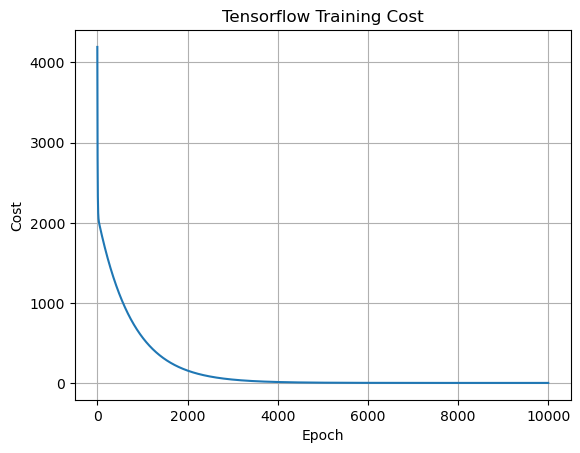

In [7]:
import matplotlib.pyplot as plt

# history.history["loss"]에는 epoch별 cost 값이 저장되어 있음 (TensorFlow2의 Keras API 기본 key 이름은 "loss")
cost_history = history.history["loss"]

plt.figure()
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Tensorflow Training Cost")
plt.grid(True)
plt.show()

1/1 [==============================] - 0s 14ms/step


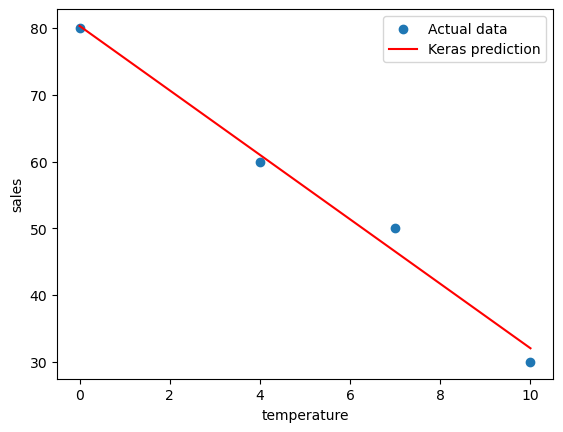

In [9]:
# model.predict(X)는 학습된 모델로 X에 대한 예측값을 계산
pred_y = model.predict(X)

plt.figure()
plt.scatter(X, y, label="Actual data")
plt.plot(X, pred_y, color="red", label="Keras prediction")
plt.xlabel("temperature")
plt.ylabel("sales")
plt.legend()
plt.show()

In [10]:
# 새로운 입력값은 2차원 형태로 넣습니다. (행 1개, 열 1개)
new_temperature = np.array([[5]], dtype="float32")
pred_sales = model.predict(new_temperature)

print(f"기온이 5도일 때 예상 판매량: {pred_sales[0][0]:.2f}개")

1/1 [==============================] - 0s 12ms/step
기온이 5도일 때 예상 판매량: 56.17개
